# 卷积神经网络：逐步构建

本实验将带你从零开始，用 NumPy 实现卷积神经网络（CNN）的核心组件，包括卷积层（CONV）和池化层（POOL）的前向传播，以及可选的反向传播。

完成本实验后，你将能够：

* 解释卷积运算的原理
* 实现最大池化与平均池化两种操作
* 识别卷积神经网络的关键组件（填充、步幅、滤波器等）及其作用
* 用 NumPy 从头搭建卷积神经网络的基础模块

**符号约定**：
- 上标 $[l]$ 表示第 $l$ 层的对象。
    - 例如：$a^{[4]}$ 表示第 4 层的激活值，$W^{[5]}$ 和 $b^{[5]}$ 是第 5 层的参数。

- 上标 $(i)$ 表示第 $i$ 个样本的对象。
    - 例如：$x^{(i)}$ 是第 $i$ 个训练样本的输入。

- 下标 $i$ 表示向量的第 $i$ 个元素。
    - 例如：$a^{[l]}_i$ 表示第 $l$ 层（全连接层）激活向量的第 $i$ 个元素。

- $n_H$、$n_W$、$n_C$ 分别表示某层的高度、宽度和通道数。对于第 $l$ 层，也可写作 $n_H^{[l]}$、$n_W^{[l]}$、$n_C^{[l]}$。
- $n_{H_{prev}}$、$n_{W_{prev}}$、$n_{C_{prev}}$ 分别表示前一层的高度、宽度和通道数，也可写作 $n_H^{[l-1]}$、$n_W^{[l-1]}$、$n_C^{[l-1]}$。

## 目录

- [1 - 依赖包](#1)
- [2 - 实验概览](#2)
- [3 - 卷积神经网络](#3)
    - [3.1 - 零填充](#3-1)
        - [练习 1 - zero_pad](#ex-1)
    - [3.2 - 单步卷积](#3-2)
        - [练习 2 - conv_single_step](#ex-2)
    - [3.3 - 卷积前向传播](#3-3)
        - [练习 3 - conv_forward](#ex-3)
- [4 - 池化层](#4)
    - [4.1 - 前向池化](#4-1)
        - [练习 4 - pool_forward](#ex-4)
- [5 - 卷积网络的反向传播（可选）](#5)
    - [5.1 - 卷积层反向传播](#5-1)
        - [5.1.1 - 计算 dA](#5-1-1)
        - [5.1.2 - 计算 dW](#5-1-2)
        - [5.1.3 - 计算 db](#5-1-3)
            - [练习 5 - conv_backward](#ex-5)
    - [5.2 - 池化层反向传播](#5-2)
        - [5.2.1 - 最大池化反向传播](#5-2-1)
            - [练习 6 - create_mask_from_window](#ex-6)
        - [5.2.2 - 平均池化反向传播](#5-2-2)
            - [练习 7 - distribute_value](#ex-7)
        - [5.2.3 - 整合：池化反向传播](#5-2-3)
            - [练习 8 - pool_backward](#ex-8)

<a name='ex-1'></a>
## 1 - 依赖包

首先导入本实验所需的全部依赖包：
- [numpy](www.numpy.org)：Python 科学计算的基础库。
- [matplotlib](http://matplotlib.org)：Python 绘图库。
- `np.random.seed(1)`：固定随机种子，保证实验结果可复现。

In [1]:
### v1.1

In [2]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
from public_tests import *

%matplotlib inline
plt.rcParams['figure.figsize'] = (5.0, 4.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

%load_ext autoreload
%autoreload 2

np.random.seed(1)

<a name='ex-2'></a>
## 2 - 实验概览

本实验将逐步实现卷积神经网络的基础模块。每个函数都有详细说明，引导你完成每一步：

- 卷积相关函数：
    - 零填充（Zero Padding）
    - 单步卷积（Convolve window）
    - 卷积前向传播（Convolution forward）
    - 卷积反向传播（可选）
- 池化相关函数：
    - 池化前向传播（Pooling forward）
    - 创建掩码（Create mask）
    - 分配梯度值（Distribute value）
    - 池化反向传播（可选）

本实验要求你在 `numpy` 中从头实现上述函数。


**注意**：每个前向传播函数都有对应的反向传播版本。因此，在前向传播的每一步，你需要将一些中间值存入缓存（cache），这些值将在反向传播计算梯度时使用。

<a name='ex-3'></a>
## 3 - 卷积神经网络

尽管深度学习框架让卷积操作变得非常简便，但卷积仍然是深度学习中最难理解的概念之一。卷积层将输入体积转换为不同大小的输出体积。


本节将逐步实现卷积层的每个组件。首先实现两个辅助函数：一个用于零填充，另一个用于执行卷积运算本身。

<a name='3-1'></a>
### 3.1 - 零填充（Zero-Padding）

零填充是指在图像边界周围添加零值像素：
 
零填充的主要作用：

- **保持空间尺寸**：使用 CONV 层时不会强制缩小高度和宽度，这对构建更深的网络至关重要。"Same" 卷积是一个重要的特殊情况，其中高度/宽度在经过一层后保持完全不变。

- **保留边界信息**：不进行填充时，图像边缘的像素对下一层的影响极少；填充后可以保留更多边界处的信息。

<a name='ex-1'></a>
### 练习 1 - zero_pad

实现下面的函数，对一批图像 X 进行零填充。使用 [np.pad](https://docs.scipy.org/doc/numpy/reference/generated/numpy.pad.html)。

例如，对形状为 $(5,5,5,5,5)$ 的数组 `a`，在第 2 维填充 1、第 4 维填充 3、其余维不填充：
```python
a = np.pad(a, ((0,0), (1,1), (0,0), (3,3), (0,0)), mode='constant', constant_values = (0,0))
```

In [3]:
def zero_pad(X, pad):
    """
    Pad with zeros all images of the dataset X. The padding is applied to the height and width of an image, 
    as illustrated in Figure 1.
    
    Argument:
    X -- python numpy array of shape (m, n_H, n_W, n_C) representing a batch of m images
    pad -- integer, amount of padding around each image on vertical and horizontal dimensions
    
    Returns:
    X_pad -- padded image of shape (m, n_H + 2 * pad, n_W + 2 * pad, n_C)
    """
    
    #(≈ 1 line)
    # X_pad = None
    ### START CODE HERE ###
    ### END CODE HERE ###
    
    return X_pad


x.shape =
 (4, 3, 3, 2)
x_pad.shape =
 (4, 9, 9, 2)
x[1,1] =
 [[ 0.90085595 -0.68372786]
 [-0.12289023 -0.93576943]
 [-0.26788808  0.53035547]]
x_pad[1,1] =
 [[0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]]
x.shape =
 (4, 3, 3, 2)
x_pad.shape =
 (4, 9, 9, 2)
x[1,1] =
 [[ 0.90085595 -0.68372786]
 [-0.12289023 -0.93576943]
 [-0.26788808  0.53035547]]
x_pad[1,1] =
 [[0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]]
[[0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0.]]
所有测试通过！


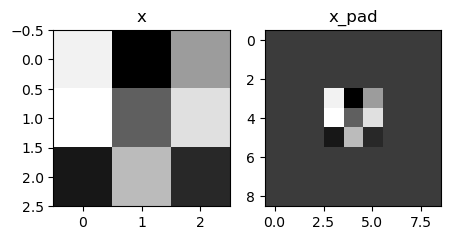

In [4]:
np.random.seed(1)
x = np.random.randn(4, 3, 3, 2)
x_pad = zero_pad(x, 3)
print ("x.shape =\n", x.shape)
print ("x_pad.shape =\n", x_pad.shape)
print ("x[1,1] =\n", x[1, 1])
print ("x_pad[1,1] =\n", x_pad[1, 1])

fig, axarr = plt.subplots(1, 2)
axarr[0].set_title('x')
axarr[0].imshow(x[0, :, :, 0])
axarr[1].set_title('x_pad')
axarr[1].imshow(x_pad[0, :, :, 0])
zero_pad_test(zero_pad)

<a name='3-2'></a>
### 3.2 - 单步卷积

本节实现卷积的单步操作：将滤波器应用于输入的某一个位置。该函数将被用来构建完整的卷积单元，其步骤为：

- 接收输入体积
- 在输入的每个位置上应用滤波器
- 输出另一个体积（通常大小不同）
 
在计算机视觉中，矩阵中的每个值对应一个像素值。将 3×3 滤波器与图像做逐元素相乘，再求和并加上偏置，即可得到一个输出值。

本练习先实现单个位置的卷积操作，后续再将其推广到全部位置，完成完整卷积。

<a name='ex-2'></a>
### 练习 2 - conv_single_step

实现 `conv_single_step()` 函数。

[参考文档](https://docs.scipy.org/doc/numpy-1.13.0/reference/generated/numpy.sum.html)。

**注意**：变量 `b` 将以 numpy 数组的形式传入。将标量（浮点数或整数）与 numpy 数组相加，结果仍为 numpy 数组。对于只包含单个值的 numpy 数组，可以用 `float()` 将其转换为标量。

In [5]:
def conv_single_step(a_slice_prev, W, b):
    """
    Apply one filter defined by parameters W on a single slice (a_slice_prev) of the output activation 
    of the previous layer.
    
    Arguments:
    a_slice_prev -- slice of input data of shape (f, f, n_C_prev)
    W -- Weight parameters contained in a window - matrix of shape (f, f, n_C_prev)
    b -- Bias parameters contained in a window - matrix of shape (1, 1, 1)
    
    Returns:
    Z -- a scalar value, the result of convolving the sliding window (W, b) on a slice x of the input data
    """

    #(≈ 3 lines of code)
    # Element-wise product between a_slice_prev and W. Do not add the bias yet.
    # s = None
    # Sum over all entries of the volume s.
    # Z = None
    # Add bias b to Z. Cast b to a float() so that Z results in a scalar value.
    # Z = None
    ### START CODE HERE ###
    ### END CODE HERE ###

    return Z


In [6]:
np.random.seed(1)
a_slice_prev = np.random.randn(4, 4, 3)
W = np.random.randn(4, 4, 3)
b = np.random.randn(1, 1, 1)

Z = conv_single_step(a_slice_prev, W, b)
print("Z =", Z)
conv_single_step_test(conv_single_step)

assert (type(Z) == np.float64), "You must cast the output to numpy float 64"
assert np.isclose(Z, -6.999089450680221), "Wrong value"

Z = -6.999089450680221
所有测试通过！


/var/folders/84/0qc33vcj4bs0_wtxz170__q40000gn/T/ipykernel_73394/1481523047.py:25: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Z = Z + float(b)


<a name='3-3'></a>
### 3.3 - 卷积前向传播

在前向传播中，我们将多个滤波器依次与输入做卷积。每次卷积产生一个二维特征图，将所有特征图堆叠后得到三维输出体积：


<a name='ex-3'></a>
### 练习 3 - conv_forward

实现下面的函数，将滤波器 `W` 与输入激活值 `A_prev` 做卷积。  
函数输入包括：
* `A_prev`：上一层输出的激活值（一批 m 个样本）；
* `W`：滤波器权重，窗口大小为 $f \times f$；
* `b`：偏置向量，每个滤波器对应一个标量偏置。

超参数字典中包含步幅（stride）和填充量（pad）。

**提示**：
1. 对形状为 (5,5,3) 的矩阵 `a_prev`，选取左上角 2×2 的切片：
```python
a_slice_prev = a_prev[0:2,0:2,:]
```
注意这给出了高度为 2、宽度为 2、深度为 3 的三维切片。

2. 定义切片时需要确定四个角：`vert_start`、`vert_end`、`horiz_start`、`horiz_end`。参考下图理解如何用 h、w、f、s 来确定这些角的位置。


**输出尺寸公式**：

$$n_H = \Bigl\lfloor \frac{n_{H_{prev}} - f + 2 \times pad}{stride} \Bigr\rfloor +1$$
$$n_W = \Bigl\lfloor \frac{n_{W_{prev}} - f + 2 \times pad}{stride} \Bigr\rfloor +1$$
$$n_C = \text{卷积中使用的滤波器数量}$$

本练习直接用 for 循环实现，无需向量化。

#### 实现提示（如果遇到困难）：

* 对以下变量使用数组切片（例如 `varname[0:1,:,3:5]`）：  
  `a_prev_pad`、`W`、`b`  
  - 可以将函数中的起始代码复制到单独的单元格中运行，验证切片的大小和维度是否符合预期。
* 确定 `vert_start`、`vert_end`、`horiz_start`、`horiz_end` 时，注意这些是前一层的索引。
  - 可以画一个示例（如 8×8 的前一层，2×2 的当前输出层）来帮助理解。
  - 输出层的索引用 `h` 和 `w` 表示。
* 确保 `a_slice_prev` 具有高度、宽度和深度三个维度。
* 注意 `a_prev_pad` 是 `A_prev_pad` 的一个子集，思考在 for 循环中应使用哪个。

In [7]:
def conv_forward(A_prev, W, b, hparameters):
    """
    Implements the forward propagation for a convolution function
    
    Arguments:
    A_prev -- output activations of the previous layer, 
        numpy array of shape (m, n_H_prev, n_W_prev, n_C_prev)
    W -- Weights, numpy array of shape (f, f, n_C_prev, n_C)
    b -- Biases, numpy array of shape (1, 1, 1, n_C)
    hparameters -- python dictionary containing "stride" and "pad"
        
    Returns:
    Z -- conv output, numpy array of shape (m, n_H, n_W, n_C)
    cache -- cache of values needed for the conv_backward() function
    """
    
    # Retrieve dimensions from A_prev's shape (≈1 line)  
    # (m, n_H_prev, n_W_prev, n_C_prev) = None
    
    # Retrieve dimensions from W's shape (≈1 line)
    # (f, f, n_C_prev, n_C) = None
    
    # Retrieve information from "hparameters" (≈2 lines)
    # stride = None
    # pad = None
    
    # Compute the dimensions of the CONV output volume using the formula given above. 
    # Hint: use int() to apply the 'floor' operation. (≈2 lines)
    # n_H = None
    # n_W = None
    
    # Initialize the output volume Z with zeros. (≈1 line)
    # Z = None
    
    # Create A_prev_pad by padding A_prev
    # A_prev_pad = None
    
    # for i in range(None):               # loop over the batch of training examples
        # a_prev_pad = None               # Select ith training example's padded activation
        # for h in range(None):           # loop over vertical axis of the output volume
            # Find the vertical start and end of the current "slice" (≈2 lines)
            # vert_start = None
            # vert_end = None
            
            # for w in range(None):       # loop over horizontal axis of the output volume
                # Find the horizontal start and end of the current "slice" (≈2 lines)
                # horiz_start = None
                # horiz_end = None
                
                # for c in range(None):   # loop over channels (= #filters) of the output volume
                                        
                    # Use the corners to define the (3D) slice of a_prev_pad (See Hint above the cell). (≈1 line)
                    # a_slice_prev = None
                    
                    # Convolve the (3D) slice with the correct filter W and bias b, to get back one output neuron. (≈3 line)
                    # weights = None
                    # biases = None
                    # Z[i, h, w, c] = None
    ### START CODE HERE ###
    
    
    
    ### END CODE HERE ###
    
    # Save information in "cache" for the backprop
    cache = (A_prev, W, b, hparameters)
    
    return Z, cache


In [8]:
np.random.seed(1)
A_prev = np.random.randn(2, 5, 7, 4)
W = np.random.randn(3, 3, 4, 8)
b = np.random.randn(1, 1, 1, 8)
hparameters = {"pad" : 1,
               "stride": 2}

Z, cache_conv = conv_forward(A_prev, W, b, hparameters)
z_mean = np.mean(Z)
z_0_2_1 = Z[0, 2, 1]
cache_0_1_2_3 = cache_conv[0][1][2][3]
print("Z's mean =\n", z_mean)
print("Z[0,2,1] =\n", z_0_2_1)
print("cache_conv[0][1][2][3] =\n", cache_0_1_2_3)

conv_forward_test_1(z_mean, z_0_2_1, cache_0_1_2_3)
conv_forward_test_2(conv_forward)


Z's mean =
 0.5511276474566768
Z[0,2,1] =
 [-2.17796037  8.07171329 -0.5772704   3.36286738  4.48113645 -2.89198428
 10.99288867  3.03171932]
cache_conv[0][1][2][3] =
 [-1.1191154   1.9560789  -0.3264995  -1.34267579]
测试1：所有测试通过！
测试2：所有测试通过！


/var/folders/84/0qc33vcj4bs0_wtxz170__q40000gn/T/ipykernel_73394/1481523047.py:25: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Z = Z + float(b)


卷积层通常还需要包含激活函数。如果需要添加激活，可在代码中加入以下内容：

```python
# 对窗口做卷积，得到一个输出神经元
Z[i, h, w, c] = ...
# 应用激活函数
A[i, h, w, c] = activation(Z[i, h, w, c])
```

本实验中无需实现激活部分。

<a name='ex-4'></a>
## 4 - 池化层

池化层（POOL）对输入的高度和宽度进行下采样，从而降低计算量，并使特征检测器对位置变化更具不变性。常见的两种池化层为：

- **最大池化层**：在 $(f, f)$ 的滑动窗口内取最大值；
- **平均池化层**：在 $(f, f)$ 的滑动窗口内取平均值。

池化层没有需要学习的参数，其超参数仅有窗口大小 $f$、步幅 $s$，有时还包括填充量（通常为 0）。

**输出尺寸公式**：

$$n_H = \Bigl\lfloor \frac{n_{H_{prev}} - f}{stride} \Bigr\rfloor +1$$
$$n_W = \Bigl\lfloor \frac{n_{W_{prev}} - f}{stride} \Bigr\rfloor +1$$
$$n_C = n_{C_{prev}}$$

<a name='ex-4'></a>
### 练习 4 - pool_forward

实现池化层的前向传播。分别实现最大池化（`mode="max"`）和平均池化（`mode="average"`）两种模式。

In [9]:
def pool_forward(A_prev, hparameters, mode = "max"):
    """
    Implements the forward pass of the pooling layer
    
    Arguments:
    A_prev -- Input data, numpy array of shape (m, n_H_prev, n_W_prev, n_C_prev)
    hparameters -- python dictionary containing "f" and "stride"
    mode -- the pooling mode you would like to use, defined as a string ("max" or "average")
    
    Returns:
    A -- output of the pool layer, a numpy array of shape (m, n_H, n_W, n_C)
    cache -- cache used in the backward pass of the pooling layer, contains the input and hparameters 
    """
    
    # Retrieve dimensions from the input shape
    (m, n_H_prev, n_W_prev, n_C_prev) = A_prev.shape
    
    # Retrieve hyperparameters from "hparameters"
    f = hparameters["f"]
    stride = hparameters["stride"]
    
    # Define the dimensions of the output
    n_H = int(1 + (n_H_prev - f) / stride)
    n_W = int(1 + (n_W_prev - f) / stride)
    n_C = n_C_prev
    
    # Initialize output matrix A
    A = np.zeros((m, n_H, n_W, n_C))              
    
    ### START CODE HERE ###
    ### END CODE HERE ###
    
    # Store the input and hparameters in "cache" for pool_backward()
    cache = (A_prev, hparameters)
    
    # Making sure your output shape is correct
    #assert(A.shape == (m, n_H, n_W, n_C))
    
    return A, cache


In [10]:
# Case 1: stride of 1
print("CASE 1:\n")
np.random.seed(1)
A_prev_case_1 = np.random.randn(2, 5, 5, 3)
hparameters_case_1 = {"stride" : 1, "f": 3}

A, cache = pool_forward(A_prev_case_1, hparameters_case_1, mode = "max")
print("mode = max")
print("A.shape = " + str(A.shape))
print("A[1, 1] =\n", A[1, 1])
A, cache = pool_forward(A_prev_case_1, hparameters_case_1, mode = "average")
print("mode = average")
print("A.shape = " + str(A.shape))
print("A[1, 1] =\n", A[1, 1])

pool_forward_test_1(pool_forward)

# Case 2: stride of 2
print("\n\033[0mCASE 2:\n")
np.random.seed(1)
A_prev_case_2 = np.random.randn(2, 5, 5, 3)
hparameters_case_2 = {"stride" : 2, "f": 3}

A, cache = pool_forward(A_prev_case_2, hparameters_case_2, mode = "max")
print("mode = max")
print("A.shape = " + str(A.shape))
print("A[0] =\n", A[0])
print()

A, cache = pool_forward(A_prev_case_2, hparameters_case_2, mode = "average")
print("mode = average")
print("A.shape = " + str(A.shape))
print("A[1] =\n", A[1])

pool_forward_test_2(pool_forward)

CASE 1:

mode = max
A.shape = (2, 3, 3, 3)
A[1, 1] =
 [[1.96710175 0.84616065 1.27375593]
 [1.96710175 0.84616065 1.23616403]
 [1.62765075 1.12141771 1.2245077 ]]
mode = average
A.shape = (2, 3, 3, 3)
A[1, 1] =
 [[ 0.44497696 -0.00261695 -0.31040307]
 [ 0.50811474 -0.23493734 -0.23961183]
 [ 0.11872677  0.17255229 -0.22112197]]
所有测试通过！

CASE 2:

mode = max
A.shape = (2, 2, 2, 3)
A[0] =
 [[[1.74481176 0.90159072 1.65980218]
  [1.74481176 1.6924546  1.65980218]]

 [[1.13162939 1.51981682 2.18557541]
  [1.13162939 1.6924546  2.18557541]]]

mode = average
A.shape = (2, 2, 2, 3)
A[1] =
 [[[-0.17313416  0.32377198 -0.34317572]
  [ 0.02030094  0.14141479 -0.01231585]]

 [[ 0.42944926  0.08446996 -0.27290905]
  [ 0.15077452  0.28911175  0.00123239]]]
所有测试通过！


**期望输出**

```
CASE 1:

mode = max
A.shape = (2, 3, 3, 3)
A[1, 1] =
 [[1.96710175 0.84616065 1.27375593]
 [1.96710175 0.84616065 1.23616403]
 [1.62765075 1.12141771 1.2245077 ]]
mode = average
A.shape = (2, 3, 3, 3)
A[1, 1] =
 [[ 0.44497696 -0.00261695 -0.31040307]
 [ 0.50811474 -0.23493734 -0.23961183]
 [ 0.11872677  0.17255229 -0.22112197]]
All tests passed!

CASE 2:

mode = max
A.shape = (2, 2, 2, 3)
A[0] =
 [[[1.74481176 0.90159072 1.65980218]
  [1.74481176 1.6924546  1.65980218]]

 [[1.13162939 1.51981682 2.18557541]
  [1.13162939 1.6924546  2.18557541]]]

mode = average
A.shape = (2, 2, 2, 3)
A[1] =
 [[[-0.17313416  0.32377198 -0.34317572]
  [ 0.02030094  0.14141479 -0.01231585]]

 [[ 0.42944926  0.08446996 -0.27290905]
  [ 0.15077452  0.28911175  0.00123239]]]
All tests passed!
```

<font color='blue'>

**知识要点**：

* 卷积通过计算输入数据与三维权重数组（滤波器）的点积来提取特征。
* 卷积的二维输出称为特征图（feature map）。
* 卷积层将输入体积转换为输出体积，输出的高度和宽度取决于超参数（滤波器大小、步幅、填充）。
* 零填充可以在不缩小空间尺寸的情况下应用卷积层，同时有助于保留边界信息。
* 池化层通过滑动窗口对输入进行下采样，减少计算量并增强特征对位置的不变性。

**恭喜！** 你已经实现了卷积网络所有层的前向传播。

本笔记本的剩余部分为可选内容，将带你实现反向传播。如果你选择继续，会看到如何利用链式法则将梯度从输出逐步传回输入。

<a name='ex-5'></a>
## 5 - 卷积神经网络的反向传播（可选）

在现代深度学习框架中，你只需实现前向传播，框架会自动处理反向传播，因此大多数工程师不需要手动推导卷积的反向传播细节。

然而，如果你希望深入理解梯度是如何在卷积网络中流动的，本节将引导你完成这一推导。

### 5.1 - 卷积层反向传播 <a name='5-1'></a>

假设已经计算出损失对卷积层输出的梯度 $dZ$，现在需要计算损失对输入 $A_{prev}$、权重 $W$ 以及偏置 $b$ 的梯度。

#### 5.1.1 - 计算 dA <a name='5-1-1'></a>

对于某一训练样本 $i$，$dA$ 的计算公式为：

$$dA \mathrel{+}= \sum_{h=0}^{n_H} \sum_{w=0}^{n_W} W_c \cdot dZ_{i,h,w,c}$$

其中 $W_c$ 是某个滤波器，$dZ_{i,h,w,c}$ 是对应输出位置的梯度标量。在每个滑动位置，用 $dZ$ 乘以滤波器并累加到 $dA_{prev}$ 对应的切片上。

#### 5.1.2 - 计算 dW <a name='5-1-2'></a>

$$dW_c \mathrel{+}= \sum_{h=0}^{n_H} \sum_{w=0}^{n_W} a_{slice} \cdot dZ_{i,h,w,c}$$

其中 $a_{slice}$ 是与当前输出位置对应的输入切片。

#### 5.1.3 - 计算 db <a name='5-1-3'></a>

$$db_c = \sum_h \sum_w dZ_{i,h,w,c}$$

即对某个滤波器 $c$，将所有位置的 $dZ$ 求和。

<a name='ex-5'></a>
### 练习 5 - conv_backward

实现 `conv_backward` 函数，完成卷积层的反向传播。

In [11]:
def conv_backward(dZ, cache):
    """
    Implement the backward propagation for a convolution function
    
    Arguments:
    dZ -- gradient of the cost with respect to the output of the conv layer (Z), numpy array of shape (m, n_H, n_W, n_C)
    cache -- cache of values needed for the conv_backward(), output of conv_forward()
    
    Returns:
    dA_prev -- gradient of the cost with respect to the input of the conv layer (A_prev),
               numpy array of shape (m, n_H_prev, n_W_prev, n_C_prev)
    dW -- gradient of the cost with respect to the weights of the conv layer (W)
          numpy array of shape (f, f, n_C_prev, n_C)
    db -- gradient of the cost with respect to the biases of the conv layer (b)
          numpy array of shape (1, 1, 1, n_C)
    """    
    
    ### START CODE HERE ###
    
    
    
                    
                    
        
    ### END CODE HERE ###
    
    # Making sure your output shape is correct
    assert(dA_prev.shape == (m, n_H_prev, n_W_prev, n_C_prev))
    
    return dA_prev, dW, db


In [12]:
# We'll run conv_forward to initialize the 'Z' and 'cache_conv",
# which we'll use to test the conv_backward function
np.random.seed(1)
A_prev = np.random.randn(10, 4, 4, 3)
W = np.random.randn(2, 2, 3, 8)
b = np.random.randn(1, 1, 1, 8)
hparameters = {"pad" : 2,
               "stride": 2}
Z, cache_conv = conv_forward(A_prev, W, b, hparameters)

# Test conv_backward
dA, dW, db = conv_backward(Z, cache_conv)

print("dA_mean =", np.mean(dA))
print("dW_mean =", np.mean(dW))
print("db_mean =", np.mean(db))

assert type(dA) == np.ndarray, "Output must be a np.ndarray"
assert type(dW) == np.ndarray, "Output must be a np.ndarray"
assert type(db) == np.ndarray, "Output must be a np.ndarray"
assert dA.shape == (10, 4, 4, 3), f"Wrong shape for dA  {dA.shape} != (10, 4, 4, 3)"
assert dW.shape == (2, 2, 3, 8), f"Wrong shape for dW {dW.shape} != (2, 2, 3, 8)"
assert db.shape == (1, 1, 1, 8), f"Wrong shape for db {db.shape} != (1, 1, 1, 8)"
assert np.isclose(np.mean(dA), 1.4524377), "Wrong values for dA"
assert np.isclose(np.mean(dW), 1.7269914), "Wrong values for dW"
assert np.isclose(np.mean(db), 7.8392325), "Wrong values for db"

print("\033[92m All tests passed.")

dA_mean = 1.4524377775388075
dW_mean = 1.7269914583139097
db_mean = 7.839232564616838
 All tests passed.


/var/folders/84/0qc33vcj4bs0_wtxz170__q40000gn/T/ipykernel_73394/1481523047.py:25: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Z = Z + float(b)


**期望输出**:
<table>
    <tr>
        <td>
            dA_mean
        </td>
        <td>
            1.45243777754
        </td>
    </tr>
    <tr>
        <td>
            dW_mean
        </td>
        <td>
            1.72699145831
        </td>
    </tr>
    <tr>
        <td>
            db_mean
        </td>
        <td>
            7.83923256462
        </td>
    </tr>

</table>


<a name='5-2'></a>
## 5.2 - 池化层反向传播

接下来实现池化层的反向传播，首先从最大池化开始。

尽管池化层没有可学习的参数，你仍然需要将梯度反向传播到前一层。这对整个网络正确更新权重至关重要。

<a name='5-2-1'></a>
### 5.2.1 - 最大池化反向传播

在最大池化中，前向传播时每个输出值都来自窗口内的最大值。因此反向传播时，梯度只流向产生最大值的那个位置，其余位置梯度为零。

<a name='ex-6'></a>
### 练习 6 - create_mask_from_window

实现 `create_mask_from_window()` 函数，从输入矩阵 $x$ 中创建掩码，标记最大值所在的位置。

In [13]:
def create_mask_from_window(x):
    """
    Creates a mask from an input matrix x, to identify the max entry of x.
    
    Arguments:
    x -- Array of shape (f, f)
    
    Returns:
    mask -- Array of the same shape as window, contains a True at the position corresponding to the max entry of x.
    """    
    # (≈1 line)
    # mask = None
    ### START CODE HERE ###
    ### END CODE HERE ###
    return mask


In [14]:
np.random.seed(1)
x = np.random.randn(2, 3)
mask = create_mask_from_window(x)
print('x = ', x)
print("mask = ", mask)

x = np.array([[-1, 2, 3],
              [2, -3, 2],
              [1, 5, -2]])

y = np.array([[False, False, False],
     [False, False, False],
     [False, True, False]])
mask = create_mask_from_window(x)

assert type(mask) == np.ndarray, "Output must be a np.ndarray"
assert mask.shape == x.shape, "Input and output shapes must match"
assert np.allclose(mask, y), "Wrong output. The True value must be at position (2, 1)"

print("\033[92m All tests passed.")

x =  [[ 1.62434536 -0.61175641 -0.52817175]
 [-1.07296862  0.86540763 -2.3015387 ]]
mask =  [[ True False False]
 [False False False]]
 All tests passed.


**Expected Output:** 

<table> 
<tr> 
<td>

**x =**
</td>

<td>

[[ 1.62434536 -0.61175641 -0.52817175] <br>
 [-1.07296862  0.86540763 -2.3015387 ]]

  </td>
</tr>

<tr> 
<td>
mask =
</td>
<td>
[[ True False False] <br>
 [False False False]]
</td>
</tr>


</table>

为什么要追踪最大值的位置？因为正是这个输入值最终影响了输出，进而影响了损失值。反向传播计算的是损失对各输入的梯度，因此只有影响最终损失的输入才会有非零梯度。通过掩码，梯度被"路由"回产生最大值的原始位置，其余位置的梯度为零。

<a name='5-2-2'></a>
### 5.2.2 - 平均池化反向传播

在最大池化中，输出仅受窗口内最大值的影响。而在平均池化中，窗口内每个元素对输出的贡献相同。因此，反向传播时需要将梯度均匀分配到窗口内的所有位置：

$$dA_{prev}[i, h: h+f, w: w+f] \mathrel{+}= \frac{dZ}{f \times f}$$

即把梯度标量 $dZ$ 均等地分配给窗口内 $f \times f$ 个位置。

<a name='ex-7'></a>
### 练习 7 - distribute_value

实现 `distribute_value()` 函数，将标量 `dz` 均匀分配到形状为 `shape` 的矩阵中。

In [15]:
def distribute_value(dz, shape):
    """
    Distributes the input value in the matrix of dimension shape
    
    Arguments:
    dz -- input scalar
    shape -- the shape (n_H, n_W) of the output matrix for which we want to distribute the value of dz
    
    Returns:
    a -- Array of size (n_H, n_W) for which we distributed the value of dz
    """    
    ### START CODE HERE ###
    ### END CODE HERE ###
    return a


In [16]:
a = distribute_value(2, (2, 2))
print('distributed value =', a)


assert type(a) == np.ndarray, "Output must be a np.ndarray"
assert a.shape == (2, 2), f"Wrong shape {a.shape} != (2, 2)"
assert np.sum(a) == 2, "Values must sum to 2"

a = distribute_value(100, (10, 10))
assert type(a) == np.ndarray, "Output must be a np.ndarray"
assert a.shape == (10, 10), f"Wrong shape {a.shape} != (10, 10)"
assert np.sum(a) == 100, "Values must sum to 100"

print("\033[92m All tests passed.")

distributed value = [[0.5 0.5]
 [0.5 0.5]]
 All tests passed.


**期望输出**: 

<table> 
<tr> 
<td>
distributed_value =
</td>
<td>
[[ 0.5  0.5]
<br\> 
[ 0.5  0.5]]
</td>
</tr>
</table>

<a name='5-2-3'></a>
### 5.2.3 - 整合：池化反向传播

现在你已经具备了实现池化层反向传播所需的全部工具。

<a name='ex-8'></a>
### 练习 8 - pool_backward

实现 `pool_backward` 函数，支持 `"max"` 和 `"average"` 两种模式。

对于 `mode="max"`：利用 `create_mask_from_window` 找到最大值位置，将梯度传回该位置。

对于 `mode="average"`：利用 `distribute_value` 将梯度均匀分配到窗口内所有位置。

In [17]:
def pool_backward(dA, cache, mode = "max"):
    """
    Implements the backward pass of the pooling layer
    
    Arguments:
    dA -- gradient of cost with respect to the output of the pooling layer, same shape as A
    cache -- cache output from the forward pass of the pooling layer, contains the layer's input and hparameters 
    mode -- the pooling mode you would like to use, defined as a string ("max" or "average")
    
    Returns:
    dA_prev -- gradient of cost with respect to the input of the pooling layer, same shape as A_prev
    """
    ### START CODE HERE ###
    
    
                    
    ### END CODE HERE ###
    
    # Making sure your output shape is correct
    assert(dA_prev.shape == A_prev.shape)
    
    return dA_prev


In [18]:
np.random.seed(1)
A_prev = np.random.randn(5, 5, 3, 2)
hparameters = {"stride" : 1, "f": 2}
A, cache = pool_forward(A_prev, hparameters)
print(A.shape)
print(cache[0].shape)
dA = np.random.randn(5, 4, 2, 2)

dA_prev1 = pool_backward(dA, cache, mode = "max")
print("mode = max")
print('mean of dA = ', np.mean(dA))
print('dA_prev1[1,1] = ', dA_prev1[1, 1])  
print()
dA_prev2 = pool_backward(dA, cache, mode = "average")
print("mode = average")
print('mean of dA = ', np.mean(dA))
print('dA_prev2[1,1] = ', dA_prev2[1, 1]) 

assert type(dA_prev1) == np.ndarray, "Wrong type"
assert dA_prev1.shape == (5, 5, 3, 2), f"Wrong shape {dA_prev1.shape} != (5, 5, 3, 2)"
assert np.allclose(dA_prev1[1, 1], [[0, 0], 
                                    [ 5.05844394, -1.68282702],
                                    [ 0, 0]]), "Wrong values for mode max"
assert np.allclose(dA_prev2[1, 1], [[0.08485462,  0.2787552], 
                                    [1.26461098, -0.25749373], 
                                    [1.17975636, -0.53624893]]), "Wrong values for mode average"
print("\033[92m All tests passed.")

(5, 4, 2, 2)
(5, 5, 3, 2)
mode = max
mean of dA =  0.14571390272918056
dA_prev1[1,1] =  [[ 0.          0.        ]
 [ 5.05844394 -1.68282702]
 [ 0.          0.        ]]

mode = average
mean of dA =  0.14571390272918056
dA_prev2[1,1] =  [[ 0.08485462  0.2787552 ]
 [ 1.26461098 -0.25749373]
 [ 1.17975636 -0.53624893]]
 All tests passed.


**期望输出**: 

mode = max:
<table> 
<tr> 
<td>

**mean of dA =**
</td>

<td>

0.145713902729

  </td>
</tr>

<tr> 
<td>
dA_prev[1,1] =
</td>
<td>
[[ 0.          0.        ] <br>
 [ 5.05844394 -1.68282702] <br>
 [ 0.          0.        ]]
</td>
</tr>
</table>

mode = average
<table> 
<tr> 
<td>

mean of dA =
</td>

<td>

0.145713902729

  </td>
</tr>

<tr> 
<td>
dA_prev[1,1] =
</td>
<td>
[[ 0.08485462  0.2787552 ] <br>
 [ 1.26461098 -0.25749373] <br>
 [ 1.17975636 -0.53624893]]
</td>
</tr>
</table>